**Libraries**

In [ ]:
!pip install h5py timm einops -q
import os
import torch
import torch.nn as nn
import timm
from einops import rearrange
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.optim as optim
from torch.amp import GradScaler, autocast
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve,
                             precision_score, f1_score)
import seaborn as sns
import h5py
from google.colab import drive



**Mount Google Drive**

In [ ]:
drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/Oral_Disease_Model'
os.makedirs(save_dir, exist_ok=True)
print("✅ Model save directory created at:", save_dir)

Mounted at /content/drive
✅ Model save directory created at: /content/drive/MyDrive/Oral_Disease_Model


**Device setup**

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
torch.cuda.empty_cache()

✅ Using device: cuda


In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_weights = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(model)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
                if self.restore_best_weights:
                    print("Restoring best model weights...")
                    model.load_state_dict(self.best_weights)
        else:
            self.best_score = score
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        self.best_weights = {k: v.clone() for k, v in model.state_dict().items()}

print("✅ EarlyStopping class defined!")

✅ EarlyStopping class defined!


**Dataset class**

In [ ]:
class OralCancerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted([
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        ])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.images = []
        self.labels = []

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            if os.path.isdir(class_dir):
                for img_file in os.listdir(class_dir):
                    if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.images.append(os.path.join(class_dir, img_file))
                        self.labels.append(self.class_to_idx[class_name])

        print(f"✅ Loaded {len(self.images)} images from {len(self.classes)} classes: {self.classes}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

print("✅ OralCancerDataset class defined!")

✅ OralCancerDataset class defined!


**Data Transforms**

In [ ]:
# Training transform - with augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation transform - clean (NO augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Test transform - clean (NO augmentation)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("✅ Transforms defined!")
print("   Train → Augmented (flip, rotation, color jitter)")
print("   Val   → Clean (resize + normalize only)")
print("   Test  → Clean (resize + normalize only)")

✅ Transforms defined!
   Train → Augmented (flip, rotation, color jitter)
   Val   → Clean (resize + normalize only)
   Test  → Clean (resize + normalize only)


**Load Dataset and create DataLoaders**

In [ ]:
dataset_path = "/content/drive/MyDrive/Oral disease dataset"

# Load full dataset first (to get all image paths)
full_dataset = OralCancerDataset(dataset_path, transform=None)

# Split sizes
total_size = len(full_dataset)          # 10,002
train_size = int(0.80 * total_size)     # 8,001
val_size   = int(0.10 * total_size)     # 1,000
test_size  = total_size - train_size - val_size  # 1,001

# Split indices
indices = list(range(total_size))
train_indices, val_indices, test_indices = torch.utils.data.random_split(
    indices, [train_size, val_size, test_size]
)

# Subset class with separate transforms
class SubsetWithTransform(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image_path = self.dataset.images[self.indices[idx]]
        label      = self.dataset.labels[self.indices[idx]]
        image      = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = SubsetWithTransform(full_dataset, train_indices, train_transform)
val_dataset   = SubsetWithTransform(full_dataset, val_indices,   val_transform)
test_dataset  = SubsetWithTransform(full_dataset, test_indices,  test_transform)

# Data loaders
batch_size   = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"✅ Data loaded successfully!")
print(f"   Train → {len(train_dataset)} images (Augmented)")
print(f"   Val   → {len(val_dataset)} images (Clean)")
print(f"   Test  → {len(test_dataset)} images (Clean)")

✅ Loaded 10002 images from 2 classes: ['oral_normal', 'oral_scc(Squamous Cell Carcinoma)']
✅ Data loaded successfully!
   Train → 8001 images (Augmented)
   Val   → 1000 images (Clean)
   Test  → 1001 images (Clean)


**Model Architecture**

**MTUNett++**

In [ ]:
class MTUNetPlusPlusEncoder(nn.Module):
    def __init__(self, in_channels=3, features=[32, 64, 128]):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, features[0], 3, padding=1, bias=False),
            nn.BatchNorm2d(features[0]),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(features[0], features[0], 3, padding=1, bias=False),
            nn.BatchNorm2d(features[0]),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(features[0], features[1], 3, padding=1, bias=False),
            nn.BatchNorm2d(features[1]),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(features[1], features[1], 3, padding=1, bias=False),
            nn.BatchNorm2d(features[1]),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = nn.Sequential(
            nn.Conv2d(features[1], features[2], 3, padding=1, bias=False),
            nn.BatchNorm2d(features[2]),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(features[2], features[2], 3, padding=1, bias=False),
            nn.BatchNorm2d(features[2]),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool1(x1))
        x3 = self.enc3(self.pool2(x2))
        return x1, x2, x3

**ViT**

In [ ]:
class ViTExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = timm.create_model(
            'vit_tiny_patch16_224', pretrained=True, num_classes=0
        )

    def forward(self, x):
        return self.model(x)  # (batch_size, 192)

**MeDSAN**

In [ ]:
class MEDSAN_Attention(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm    = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.norm(x)
        x = x.unsqueeze(0)
        attn_out, _ = self.attn(x, x, x)
        attn_out = self.dropout(attn_out)
        return attn_out.squeeze(0)


**Fusion Model**

In [ ]:
class FusionModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.mtunet = MTUNetPlusPlusEncoder()
        self.vit    = ViTExtractor()
        self.medsan = MEDSAN_Attention(dim=192, dropout=0.1)

        self.mtunet_proj = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 192),
            nn.Dropout(0.1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(192 * 2, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        _, _, mtunet_feat = self.mtunet(x)
        mtunet_feat = self.mtunet_proj(mtunet_feat)
        vit_feat    = self.vit(x)
        att_feat    = self.medsan(vit_feat)
        fused_feat  = torch.cat([mtunet_feat, att_feat], dim=1)
        return self.classifier(fused_feat)


model = FusionModel(num_classes=2).to(device)
print("✅ Fusion Model (MTUNet++ + ViT + MeDSAN) created successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

✅ Fusion Model (MTUNet++ + ViT + MeDSAN) created successfully!


**Loss, Optimizer, Schedulet**

In [ ]:
criterion      = nn.CrossEntropyLoss()
optimizer      = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler      = optim.lr_scheduler.ReduceLROnPlateau(
                     optimizer, mode='min', patience=3, factor=0.5)
scaler         = GradScaler()
early_stopping = EarlyStopping(patience=5, min_delta=0.001, restore_best_weights=True)

print("✅ Loss, Optimizer, Scheduler defined!")
print("   Loss      → CrossEntropyLoss")
print("   Optimizer → AdamW (lr=1e-4, weight_decay=0.01)")
print("   Scheduler → ReduceLROnPlateau (patience=3)")

✅ Loss, Optimizer, Scheduler defined!
   Loss      → CrossEntropyLoss
   Optimizer → AdamW (lr=1e-4, weight_decay=0.01)
   Scheduler → ReduceLROnPlateau (patience=3)


**Training Loop**

In [ ]:
epochs          = 30
best_accuracy   = 0.0
train_acc_list  = []
val_acc_list    = []
train_loss_list = []
val_loss_list   = []

print("🚀 Starting Training...\n")

for epoch in range(epochs):

    # ── Training Phase ──
    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
    for images, labels in train_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        with autocast(device_type='cuda'):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        _, predicted  = torch.max(outputs.data, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()
        running_loss += loss.item()

        train_bar.set_postfix(
            loss=running_loss / (train_bar.n + 1),
            acc=100 * correct / total
        )

    train_accuracy = 100 * correct / total
    train_loss     = running_loss / len(train_loader)
    train_acc_list.append(train_accuracy)
    train_loss_list.append(train_loss)

    # ── Validation Phase ──
    model.eval()
    val_correct      = 0
    val_total        = 0
    val_running_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]'):
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            _, predicted  = torch.max(outputs.data, 1)
            val_total    += labels.size(0)
            val_correct  += (predicted == labels).sum().item()
            val_running_loss += loss.item()

    val_accuracy = 100 * val_correct / val_total
    val_loss     = val_running_loss / len(val_loader)
    val_acc_list.append(val_accuracy)
    val_loss_list.append(val_loss)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"  Train → Loss: {train_loss:.4f} | Acc: {train_accuracy:.2f}%")
    print(f"  Val   → Loss: {val_loss:.4f}   | Acc: {val_accuracy:.2f}%")

    # ── Save Best Model ──
    if val_accuracy > best_accuracy:
        best_accuracy   = val_accuracy
        model_save_path = os.path.join(save_dir, 'best_oral_disease_model.h5')
        with h5py.File(model_save_path, 'w') as f:
            for key, value in model.state_dict().items():
                f.create_dataset(key, data=value.cpu().numpy())
            f.attrs['epoch']          = epoch
            f.attrs['val_accuracy']   = val_accuracy
            f.attrs['train_accuracy'] = train_accuracy
        print(f"  🎯 Best model saved! Val Acc: {val_accuracy:.2f}%")

    # ── Scheduler & Early Stopping ──
    scheduler.step(val_loss)
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print(f"\n⛔ Early stopping triggered at epoch {epoch+1}")
        break

print(f"\n✅ Training complete! Best Val Accuracy: {best_accuracy:.2f}%")

🚀 Starting Training...



Epoch 1/30 [Val]: 100%|██████████| 32/32 [01:51<00:00,  3.49s/it]



Epoch 1/30
  Train → Loss: 0.6923 | Acc: 57.17%
  Val   → Loss: 0.7387   | Acc: 58.20%
  🎯 Best model saved! Val Acc: 58.20%


Epoch 2/30 [Val]: 100%|██████████| 32/32 [00:06<00:00,  4.72it/s]



Epoch 2/30
  Train → Loss: 0.4951 | Acc: 75.86%
  Val   → Loss: 0.3289   | Acc: 87.90%
  🎯 Best model saved! Val Acc: 87.90%


...


Epoch 8/30
  Train → Loss: 0.1220 | Acc: 96.01%
  Val   → Loss: 0.1801   | Acc: 93.30%
EarlyStopping counter: 3 out of 5


Epoch 9/30 [Val]: 100%|██████████| 32/32 [00:08<00:00,  3.81it/s]



Epoch 9/30
  Train → Loss: 0.1026 | Acc: 96.96%
  Val   → Loss: 0.1101   | Acc: 97.70%
  🎯 Best model saved! Val Acc: 97.70%
EarlyStopping counter: 4 out of 5


Epoch 10/30 [Val]: 100%|██████████| 32/32 [00:06<00:00,  4.80it/s]



Epoch 10/30
  Train → Loss: 0.0963 | Acc: 98.25%
  Val   → Loss: 0.1240   | Acc: 98.00%
  🎯 Best model saved! Val Acc: 98.00%
EarlyStopping counter: 5 out of 5
Restoring best model weights...

⛔ Early stopping triggered at epoch 10

✅ Training complete! Best Val Accuracy: 98.00%


**Load Best Model**

In [ ]:
model_load_path = os.path.join(save_dir, 'best_oral_disease_model.h5')
state_dict      = {}

with h5py.File(model_load_path, 'r') as f:
    for key in f.keys():
        state_dict[key] = torch.tensor(np.array(f[key]))
    epoch_saved      = f.attrs['epoch']
    val_acc_saved    = f.attrs['val_accuracy']
    train_acc_saved  = f.attrs['train_accuracy']

model.load_state_dict(state_dict)
print(f"✅ Best model loaded!")
print(f"   Saved at Epoch      → {int(epoch_saved)+1}")
print(f"   Train Accuracy      → {train_acc_saved:.2f}%")
print(f"   Validation Accuracy → {val_acc_saved:.2f}%")

✅ Best model loaded!
   Saved at Epoch      → 10
   Train Accuracy      → 98.25%
   Validation Accuracy → 98.00%


**Test Evaluation + All Metrics**

In [ ]:
model.eval()
all_predictions = []
all_labels      = []
all_probs       = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images  = images.to(device)
        labels  = labels.to(device)
        outputs = model(images)

        probs        = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # OSCC probability

all_predictions = np.array(all_predictions)
all_labels      = np.array(all_labels)
all_probs       = np.array(all_probs)

Testing: 100%|██████████| 32/32 [01:52<00:00,  3.51s/it]


**Calculate All Metrics**

In [ ]:
test_accuracy = 100 * np.sum(all_predictions == all_labels) / len(all_labels)
auc_score     = roc_auc_score(all_labels, all_probs)

report_dict   = classification_report(
    all_labels, all_predictions,
    target_names=full_dataset.classes,
    output_dict=True
)

precision    = report_dict['weighted avg']['precision']
recall       = report_dict['weighted avg']['recall']
f1           = report_dict['weighted avg']['f1-score']
sensitivity  = report_dict[full_dataset.classes[1]]['recall'] #OSCC
specificity  = report_dict[full_dataset.classes[0]]['recall'] #Normal

print("\n" + "="*50)
print("         📊 FINAL TEST RESULTS")
print("="*50)
print(f"  Accuracy    → {test_accuracy:.2f}%")
print(f"  AUC-ROC     → {auc_score:.4f}")
print(f"  Precision   → {precision:.4f}")
print(f"  Recall      → {recall:.4f}")
print(f"  F1-Score    → {f1:.4f}")
print(f"  Sensitivity → {sensitivity:.4f}  (OSCC detection rate)")
print(f"  Specificity → {specificity:.4f}  (Normal detection rate)")
print("="*50)


         📊 FINAL TEST RESULTS
  Accuracy    → 98.50%
  AUC-ROC     → 0.9989
  Precision   → 0.9850
  Recall      → 0.9850
  F1-Score    → 0.9850
  Sensitivity → 0.9860  (OSCC detection rate)
  Specificity → 0.9840  (Normal detection rate)


**Plots & Visualization**

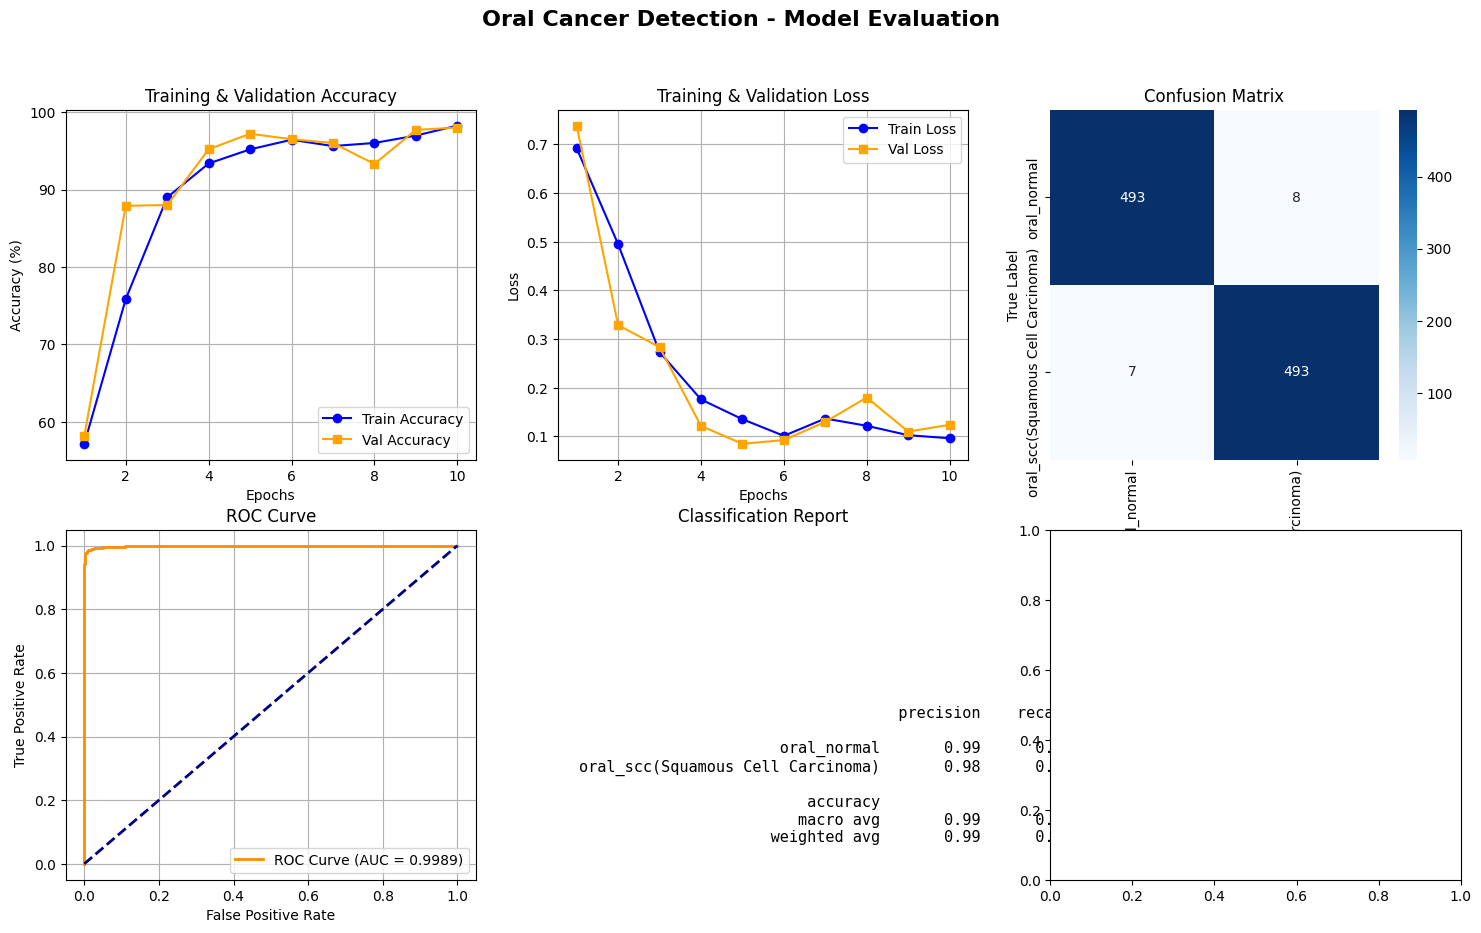

<Figure size 640x480 with 0 Axes>

✅ All plots saved to Google Drive!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Oral Cancer Detection - Model Evaluation', fontsize=16, fontweight='bold')

#Accuracy Curve
axes[0, 0].plot(range(1, len(train_acc_list)+1), train_acc_list,
                label='Train Accuracy', marker='o', color='blue')
axes[0, 0].plot(range(1, len(val_acc_list)+1), val_acc_list,
                label='Val Accuracy', marker='s', color='orange')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Training & Validation Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

#Loss Curve
axes[0, 1].plot(range(1, len(train_loss_list)+1), train_loss_list,
                label='Train Loss', marker='o', color='blue')
axes[0, 1].plot(range(1, len(val_loss_list)+1), val_loss_list,
                label='Val Loss', marker='s', color='orange')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Training & Validation Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

#Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes,
            ax=axes[0, 2])
axes[0, 2].set_xlabel('Predicted Label')
axes[0, 2].set_ylabel('True Label')
axes[0, 2].set_title('Confusion Matrix')

#ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC Curve (AUC = {auc_score:.4f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True)

#Classification Report
report_text = classification_report(
    all_labels, all_predictions,
    target_names=full_dataset.classes
)
axes[1, 1].text(0.05, 0.05, report_text,
                {'fontsize': 11}, fontproperties='monospace',
                verticalalignment='bottom')
axes[1, 1].axis('off')
axes[1, 1].set_title('Classification Report')
plt.show()

#Metrics Bar Chart
metrics_names  = ['Accuracy', 'AUC-ROC', 'Precision', 'Recall',
                  'F1', 'Sensitivity', 'Specificity']
metrics_values = [test_accuracy/100, auc_score, precision, recall,
                  f1, sensitivity, specificity]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0',
          '#F44336', '#00BCD4', '#795548']

bars = axes[1, 2].bar(metrics_names, metrics_values,
                      color=colors, edgecolor='black')
axes[1, 2].set_ylim(0, 1.15)
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('All Metrics Summary')
axes[1, 2].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, metrics_values):
    axes[1, 2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{val:.3f}', ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(save_dir, 'model_evaluation-v2.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ All plots saved to Google Drive!")



**Verify Save Model**

In [ ]:
with h5py.File(model_load_path, 'r') as f:
    epoch_saved      = f.attrs['epoch']
    val_acc_saved    = f.attrs['val_accuracy']
    train_acc_saved  = f.attrs['train_accuracy']
    num_layers_saved = len(f.keys())

print("="*45)
print("      ✅ SAVED MODEL VERIFICATION")
print("="*45)
print(f"  Saved at Epoch      → {int(epoch_saved)+1}")
print(f"  Train Accuracy      → {train_acc_saved:.2f}%")
print(f"  Validation Accuracy → {val_acc_saved:.2f}%")
print(f"  Total layers saved  → {num_layers_saved}")
print("="*45)

      ✅ SAVED MODEL VERIFICATION
  Saved at Epoch      → 10
  Train Accuracy      → 98.25%
  Validation Accuracy → 98.00%
  Total layers saved  → 217
